# 03 — Weather Trend Forecasting

**PM Accelerator — Advanced track**  
**Target:** daily temperature (°C)  
**Time column:** `last_updated` (aggregated to daily)  
**Location:** Kyiv, Ukraine (strong seasonality — clearer forecasting signal)

---

## Why this notebook exists

Assessment requirements covered here:
1. Build forecasting models using `last_updated`
2. Evaluate with multiple metrics
3. Compare **multiple** models
4. Build an **ensemble**

## Forecasting idea (simple)

We turn history into: *given recent days, predict tomorrow's temperature.*

```text
past temperatures -> model -> next day's temperature
```


## 1. Imports & paths


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ROOT = Path("..").resolve()
CLEAN_PATH = ROOT / "data" / "processed" / "weather_cleaned.csv"
OUT_DIR = ROOT / "outputs" / "forecasting"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Output folder:", OUT_DIR)


Output folder: .\outputs\forecasting


## 2. Build a daily temperature series from `last_updated`

### Why daily, not every raw timestamp?
Raw rows can have multiple updates per day. Forecasting is clearer on a **regular daily series**.

### How
1. Choose a city with long history **and** seasonal variation
2. Use `last_updated` and resample to daily mean temperature
3. Fill small gaps so the series is continuous

### Why Kyiv (not just the city with most rows)?
Tropical cities (e.g. Bujumbura) have low day-to-day temperature range.
A simple moving average can look "good" there, but models learn little.
Kyiv has clear winter/summer swings — better to demonstrate forecasting skill.


,country,location_name,n_obs
36,Burundi,Bujumbura,791
260,Ukraine,Kyiv,791
278,Yemen,Sanaa,791
49,Chad,N'djamena,791
86,Ghana,Accra,791


Selected: Kyiv, Ukraine
Daily points: 793
Date range: 2024-05-16 -> 2026-07-17
Missing days before fill: 3
Any NaN after fill? False


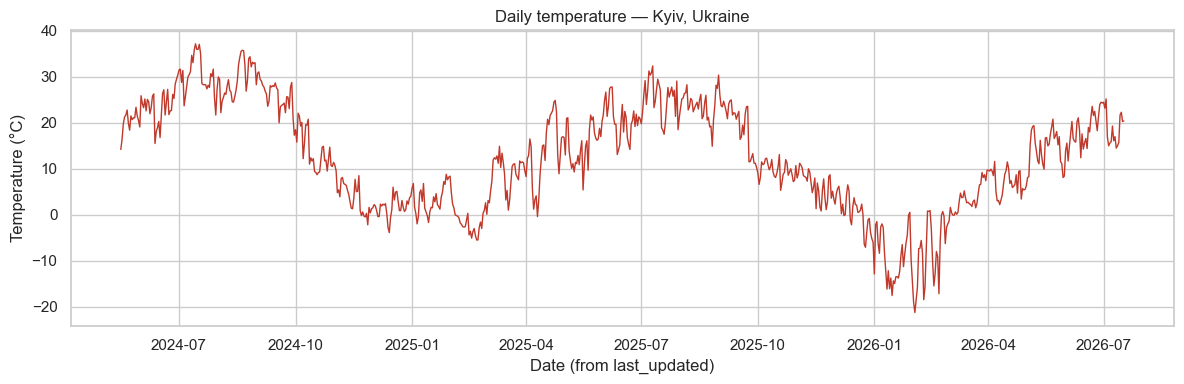

In [2]:
df = pd.read_csv(CLEAN_PATH, low_memory=False)
df["last_updated"] = pd.to_datetime(df["last_updated"])

coverage = (
    df.groupby(["country", "location_name"])
    .size()
    .reset_index(name="n_obs")
    .sort_values("n_obs", ascending=False)
)
display(coverage.head(5))

# Prefer a seasonal city for clearer forecasts (fallback: most observations)
COUNTRY, CITY = "Ukraine", "Kyiv"
if not ((df["country"] == COUNTRY) & (df["location_name"] == CITY)).any():
    COUNTRY = coverage.iloc[0]["country"]
    CITY = coverage.iloc[0]["location_name"]
print(f"Selected: {CITY}, {COUNTRY}")

city = df[(df["country"] == COUNTRY) & (df["location_name"] == CITY)].copy()
city = city.sort_values("last_updated")

daily = (
    city.set_index("last_updated")
    .resample("D")["temperature_celsius"]
    .mean()
    .to_frame("temp")
)

n_missing_before = int(daily["temp"].isna().sum())
daily["temp"] = daily["temp"].ffill().bfill()

print("Daily points:", len(daily))
print("Date range:", daily.index.min().date(), "->", daily.index.max().date())
print("Missing days before fill:", n_missing_before)
print("Any NaN after fill?", daily["temp"].isna().any())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily["temp"], color="#c0392b", linewidth=1)
ax.set_title(f"Daily temperature — {CITY}, {COUNTRY}")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Date (from last_updated)")
plt.tight_layout()
fig.savefig(OUT_DIR / "01_daily_series.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Train / test split by TIME (not random)

### Why not random shuffle?
In forecasting, the test set must be **the future**.
If you shuffle, the model can see the future during training -> fake good scores (**leakage**).

### How we split
- **Train:** first 80% of days
- **Test:** last 20% of days (most recent period)


Train: 634 days | 2024-05-16 -> 2026-02-08
Test : 159 days | 2026-02-09 -> 2026-07-17


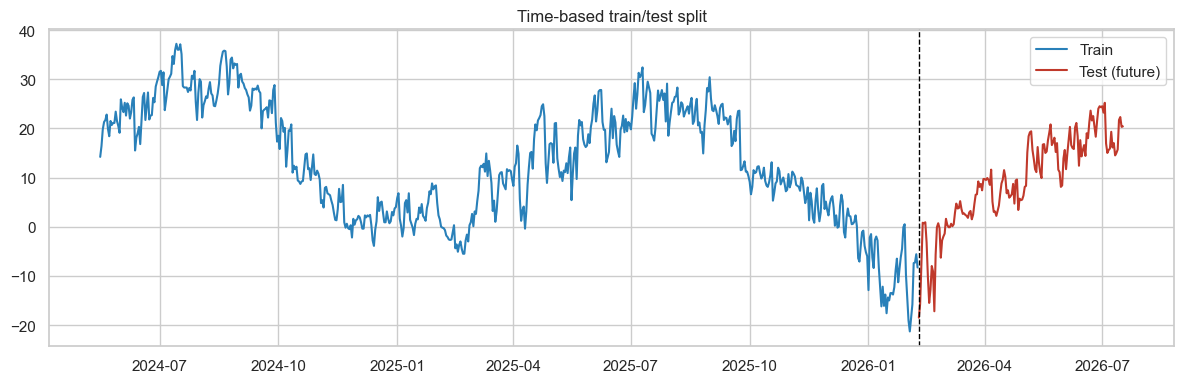

In [3]:
n = len(daily)
split_idx = int(n * 0.80)

train = daily.iloc[:split_idx].copy()
test = daily.iloc[split_idx:].copy()

print(f"Train: {len(train)} days | {train.index.min().date()} -> {train.index.max().date()}")
print(f"Test : {len(test)} days | {test.index.min().date()} -> {test.index.max().date()}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train.index, train["temp"], label="Train", color="#2980b9")
ax.plot(test.index, test["temp"], label="Test (future)", color="#c0392b")
ax.axvline(test.index.min(), color="black", linestyle="--", linewidth=1)
ax.set_title("Time-based train/test split")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "02_train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Evaluation metrics

| Metric | Meaning | Good when |
|--------|---------|-----------|
| **MAE** | average absolute error in °C | lower |
| **RMSE** | like MAE but punishes big mistakes more | lower |
| **MAPE** | average % error | lower |
| **R²** | how much variance explained (1 = perfect) | higher |

We compare every model with the same metrics on the **test** period.


In [4]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def evaluate(y_true, y_pred, name):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE_%": mape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


results = []
predictions = pd.DataFrame({"actual": test["temp"]})
print("Metric helpers ready.")


Metric helpers ready.


## 5. Model A — Naive baseline (last value)

### Idea
Tomorrow ≈ today (last observed temperature).

### Why start here?
Any serious model should beat this simple baseline.
If it cannot, the fancy model is not useful.


In [5]:
naive_pred = test["temp"].shift(1)
naive_pred.iloc[0] = train["temp"].iloc[-1]

predictions["naive"] = naive_pred.values
results.append(evaluate(test["temp"], naive_pred, "Naive (lag-1)"))
pd.DataFrame(results).round(3)


,model,MAE,RMSE,MAPE_%,R2
0,Naive (lag-1),2.232,3.127,79.193,0.884


## 6. Model B — Moving average baseline

### Idea
Tomorrow ≈ average of the last *k* days.

Smoother than naive; still very simple.


In [6]:
WINDOW = 7

full_ma = daily["temp"].rolling(WINDOW).mean()
ma_pred = full_ma.shift(1).loc[test.index]

predictions["moving_avg_7"] = ma_pred.values
results.append(evaluate(test["temp"], ma_pred, "Moving Avg (7d)"))
pd.DataFrame(results).round(3)


,model,MAE,RMSE,MAPE_%,R2
0,Naive (lag-1),2.232,3.127,79.193,0.884
1,Moving Avg (7d),3.214,4.137,175.029,0.796


## 7. Lag features for ML models

### Idea
Machine learning needs a table of inputs (X) and target (y).

For day *t*:
- **y** = temperature on day *t*
- **X** = temperatures on days *t-1, t-2, ...* plus calendar features

### Why calendar features?
Month / day-of-week help capture seasonality without a special seasonal model.


In [7]:
LAGS = [1, 2, 3, 7, 14]

feat = daily.copy()
for lag in LAGS:
    feat[f"lag_{lag}"] = feat["temp"].shift(lag)

feat["roll_mean_7"] = feat["temp"].shift(1).rolling(7).mean()
feat["roll_std_7"] = feat["temp"].shift(1).rolling(7).std()
feat["month"] = feat.index.month
feat["dayofweek"] = feat.index.dayofweek
feat["dayofyear"] = feat.index.dayofyear

feat = feat.dropna()
feature_cols = [c for c in feat.columns if c != "temp"]

X = feat[feature_cols]
y = feat["temp"]

X_train = X.loc[X.index <= train.index.max()]
y_train = y.loc[X_train.index]
X_test = X.loc[X.index >= test.index.min()]
y_test = y.loc[X_test.index]

print("Features:", feature_cols)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
X_train.head(3)


Features: ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'roll_mean_7', 'roll_std_7', 'month', 'dayofweek', 'dayofyear']
X_train: (620, 10) | X_test: (159, 10)


,lag_1,lag_2,lag_3,lag_7,lag_14,roll_mean_7,roll_std_7,month,dayofweek,dayofyear
last_updated,,,,,,,,,,
2024-05-30,21.5,23.4,21.1,18.4,14.2,21.100000,1.475353,5,3,151
2024-05-31,20.5,21.5,23.4,21.5,16.4,21.400000,0.957427,5,4,152
2024-06-01,19.1,20.5,21.5,20.7,19.8,21.057143,1.288225,6,5,153


## 8. Model C — Ridge regression (linear)

### Idea
Linear combination of lag features.
Ridge adds regularization so coefficients stay stable.


In [8]:
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train, y_train)
ridge_pred = pd.Series(ridge.predict(X_test), index=X_test.index)

predictions.loc[ridge_pred.index, "ridge"] = ridge_pred
results.append(evaluate(y_test, ridge_pred, "Ridge (lags)"))
pd.DataFrame(results).round(3)


,model,MAE,RMSE,MAPE_%,R2
0,Naive (lag-1),2.232,3.127,79.193,0.884
1,Moving Avg (7d),3.214,4.137,175.029,0.796
2,Ridge (lags),2.204,2.977,82.709,0.894


## 9. Model D — Random Forest

### Idea
Many decision trees voting together.
Good at non-linear patterns (e.g. sudden weather shifts).


In [9]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_pred = pd.Series(rf.predict(X_test), index=X_test.index)

predictions.loc[rf_pred.index, "random_forest"] = rf_pred
results.append(evaluate(y_test, rf_pred, "Random Forest"))
pd.DataFrame(results).round(3)


,model,MAE,RMSE,MAPE_%,R2
0,Naive (lag-1),2.232,3.127,79.193,0.884
1,Moving Avg (7d),3.214,4.137,175.029,0.796
2,Ridge (lags),2.204,2.977,82.709,0.894
3,Random Forest,2.353,3.136,96.868,0.883


## 10. Model E — Gradient Boosting

### Idea
Trees built **one after another**, each fixing previous errors.
Often strong on tabular forecasting features.


In [10]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE,
)
gb.fit(X_train, y_train)
gb_pred = pd.Series(gb.predict(X_test), index=X_test.index)

predictions.loc[gb_pred.index, "gradient_boosting"] = gb_pred
results.append(evaluate(y_test, gb_pred, "Gradient Boosting"))
pd.DataFrame(results).round(3)


,model,MAE,RMSE,MAPE_%,R2
0,Naive (lag-1),2.232,3.127,79.193,0.884
1,Moving Avg (7d),3.214,4.137,175.029,0.796
2,Ridge (lags),2.204,2.977,82.709,0.894
3,Random Forest,2.353,3.136,96.868,0.883
4,Gradient Boosting,2.519,3.348,108.580,0.867


## 11. Ensemble — average of strong models

### Idea
Combine predictions so one model's mistakes can be cancelled by another.

We use a simple average of:
- Ridge
- Random Forest
- Gradient Boosting

(Advanced requirement: ensemble to improve accuracy.)


In [11]:
ensemble_pred = (ridge_pred + rf_pred + gb_pred) / 3.0
predictions.loc[ensemble_pred.index, "ensemble_mean"] = ensemble_pred
results.append(evaluate(y_test, ensemble_pred, "Ensemble (mean)"))

voting = VotingRegressor(
    estimators=[
        ("ridge", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
        (
            "rf",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=3,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
        (
            "gb",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
voting.fit(X_train, y_train)
voting_pred = pd.Series(voting.predict(X_test), index=X_test.index)
predictions.loc[voting_pred.index, "ensemble_voting"] = voting_pred
results.append(evaluate(y_test, voting_pred, "Ensemble (VotingRegressor)"))

metrics_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
metrics_df.round(3)


,model,MAE,RMSE,MAPE_%,R2
0,Ridge (lags),2.204,2.977,82.709,0.894
1,Naive (lag-1),2.232,3.127,79.193,0.884
2,Ensemble (mean),2.295,3.071,93.470,0.888
3,Ensemble (VotingRegressor),2.295,3.071,93.470,0.888
4,Random Forest,2.353,3.136,96.868,0.883
5,Gradient Boosting,2.519,3.348,108.580,0.867
6,Moving Avg (7d),3.214,4.137,175.029,0.796


## 12. Compare models visually


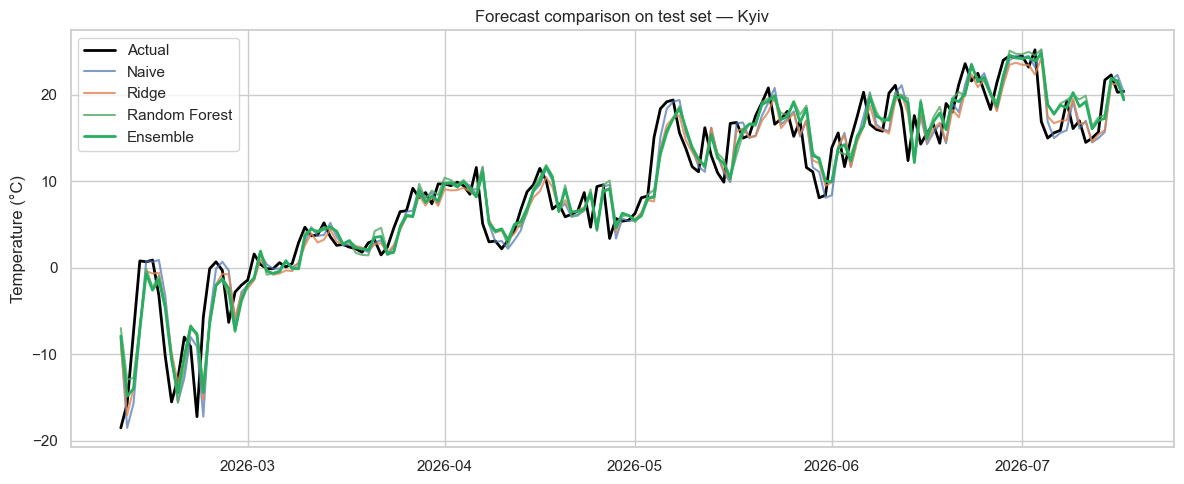

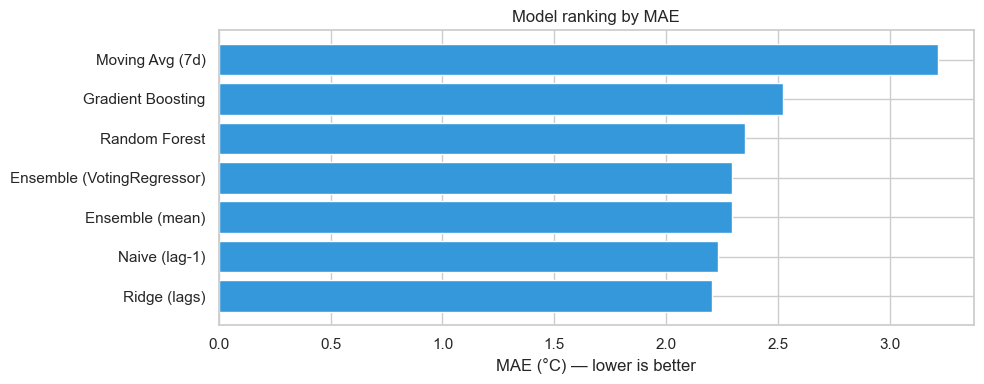

In [12]:
plot_idx = y_test.index

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_idx, y_test.values, label="Actual", color="black", linewidth=2)
ax.plot(plot_idx, predictions.loc[plot_idx, "naive"], label="Naive", alpha=0.7)
ax.plot(plot_idx, predictions.loc[plot_idx, "ridge"], label="Ridge", alpha=0.8)
ax.plot(plot_idx, predictions.loc[plot_idx, "random_forest"], label="Random Forest", alpha=0.8)
ax.plot(plot_idx, predictions.loc[plot_idx, "ensemble_mean"], label="Ensemble", linewidth=2, color="#27ae60")
ax.set_title(f"Forecast comparison on test set — {CITY}")
ax.set_ylabel("Temperature (°C)")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "03_forecast_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_metrics = metrics_df.sort_values("MAE")
ax.barh(plot_metrics["model"], plot_metrics["MAE"], color="#3498db")
ax.set_xlabel("MAE (°C) — lower is better")
ax.set_title("Model ranking by MAE")
plt.tight_layout()
fig.savefig(OUT_DIR / "04_mae_ranking.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Feature importance (Random Forest)

### Why
Shows which inputs the forest used most (lags, rolling stats, calendar).
Useful for the report and Advanced feature importance discussion.


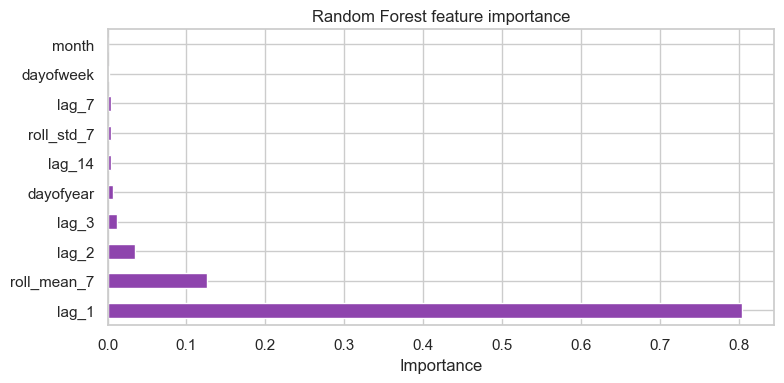

,importance
lag_1,0.804
roll_mean_7,0.126
lag_2,0.034
lag_3,0.012
dayofyear,0.007
lag_14,0.005
roll_std_7,0.004
lag_7,0.004
dayofweek,0.002
month,0.001


In [13]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
imp.plot(kind="barh", ax=ax, color="#8e44ad")
ax.set_title("Random Forest feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
fig.savefig(OUT_DIR / "05_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

imp.round(3).to_frame("importance")


## 14. Save results


In [14]:
metrics_df.to_csv(OUT_DIR / "model_metrics.csv", index=False)
predictions.to_csv(OUT_DIR / "test_predictions.csv")

summary = {
    "city": CITY,
    "country": COUNTRY,
    "n_daily_points": len(daily),
    "train_days": len(train),
    "test_days": len(test),
    "best_model_by_MAE": metrics_df.iloc[0]["model"],
    "best_MAE": float(metrics_df.iloc[0]["MAE"]),
    "best_RMSE": float(metrics_df.iloc[0]["RMSE"]),
    "naive_MAE": float(metrics_df.loc[metrics_df["model"] == "Naive (lag-1)", "MAE"].iloc[0]),
}
pd.Series(summary).to_csv(OUT_DIR / "forecast_summary.csv", header=["value"])

print("Saved to", OUT_DIR)
print("\n=== SUMMARY ===")
display(pd.Series(summary))
print("\n=== METRICS (sorted by MAE) ===")
display(metrics_df.round(3))


Saved to .\outputs\forecasting

=== SUMMARY ===


city                         Kyiv
country                   Ukraine
n_daily_points                793
train_days                    634
test_days                     159
best_model_by_MAE    Ridge (lags)
best_MAE                 2.203825
best_RMSE                 2.97736
naive_MAE                2.232075
dtype: object


=== METRICS (sorted by MAE) ===


,model,MAE,RMSE,MAPE_%,R2
0,Ridge (lags),2.204,2.977,82.709,0.894
1,Naive (lag-1),2.232,3.127,79.193,0.884
2,Ensemble (mean),2.295,3.071,93.470,0.888
3,Ensemble (VotingRegressor),2.295,3.071,93.470,0.888
4,Random Forest,2.353,3.136,96.868,0.883
5,Gradient Boosting,2.519,3.348,108.580,0.867
6,Moving Avg (7d),3.214,4.137,175.029,0.796
